# Career Orientation — Model Training (v2)

Train a career classifier on the generated profiles.

**Architecture:** partially-unfrozen `all-MiniLM-L6-v2` (last 2 layers trainable) + 3-layer head with BatchNorm (384 → 256 → 128 → 6)

**Improvements over v1:**
- Unfreeze last 2 transformer layers for domain adaptation
- Differential learning rates (encoder 5e-6 vs head 2e-4)
- BatchNorm in classifier head
- Label smoothing (0.1)
- ReduceLROnPlateau scheduler
- 40 epochs with early stopping (patience=8)

## Cell 1 — Install & Imports

In [6]:
import sys, os
from pathlib import Path

# Use the venv Python — run this notebook with the "Career Orientation (venv)" kernel
VENV_DIR = Path('..') / 'venv'
TORCH_LIB = VENV_DIR / 'Lib' / 'site-packages' / 'torch' / 'lib'

# Fix DLL loading on OneDrive/network paths (Windows needs explicit DLL directory)
if TORCH_LIB.exists() and hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(str(TORCH_LIB.resolve()))

print("Ready — using venv kernel.")

Ready — using venv kernel.


In [7]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('..') / 'data'
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(exist_ok=True)

RAW_DATA_PATH    = DATA_DIR / 'raw_profiles.json'
LABEL_MAP_PATH   = DATA_DIR / 'label_map.json'
BEST_MODEL_PATH  = MODELS_DIR / 'best_model.pt'
FINAL_MODEL_PATH = MODELS_DIR / 'career_model.pt'

# ── Hyperparameters ───────────────────────────────────────────────────────────
SEED = 42
EPOCHS = 40
BATCH_SIZE = 32
HEAD_LR = 2e-4
ENCODER_LR = 5e-6           # much lower for fine-tuned encoder layers
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
PATIENCE = 8                 # early stopping patience
UNFREEZE_LAST_N = 2          # transformer layers to unfreeze

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Cell 2 — Load Data & Preprocessing

In [8]:
def profile_to_text(profile: dict) -> str:
    """Serialize a profile dict to a fixed-format text string."""
    skills    = ', '.join(profile.get('skills', []))
    interests = ', '.join(profile.get('interests', []))
    projects  = '. '.join(profile.get('projects', []))
    goals     = profile.get('goals', {})
    acad      = profile.get('academic_performance', {})
    return (
        f"Skills: {skills}. "
        f"Interests: {interests}. "
        f"Projects: {projects}. "
        f"Goals: target {goals.get('target_field', 'N/A')}, "
        f"salary {goals.get('salary_expectation', 'N/A')}, "
        f"remote {goals.get('remote_preference', 'N/A')}. "
        f"Academic: Math {acad.get('math', 0)}/20, "
        f"Sciences {acad.get('sciences', 0)}/20, "
        f"Languages {acad.get('languages', 0)}/20, "
        f"Arts {acad.get('arts', 0)}/20."
    )


# ── Load raw profiles ────────────────────────────────────────────────────────
assert RAW_DATA_PATH.exists(), f'Data not found at {RAW_DATA_PATH}. Run generate_data notebook first.'

with open(RAW_DATA_PATH, 'r', encoding='utf-8') as f:
    raw_profiles = json.load(f)
print(f'Loaded {len(raw_profiles)} profiles')

texts  = [profile_to_text(p) for p in raw_profiles]
labels = [p['label'] for p in raw_profiles]

# ── Label encoding (alphabetical) ────────────────────────────────────────────
sorted_classes = sorted(set(labels))
label_to_id = {cls: idx for idx, cls in enumerate(sorted_classes)}
id_to_label = {idx: cls for cls, idx in label_to_id.items()}
label_ids   = [label_to_id[l] for l in labels]

print('Label mapping:')
for cls, idx in label_to_id.items():
    print(f'  {idx}: {cls}')

with open(LABEL_MAP_PATH, 'w', encoding='utf-8') as f:
    json.dump(label_to_id, f, indent=2)

# ── Distribution ──────────────────────────────────────────────────────────────
df_raw = pd.DataFrame({'label': labels})
print(f'\n{df_raw["label"].value_counts().to_string()}')

# ── Train / Val / Test split 70/15/15 ────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, label_ids, test_size=0.30, stratify=label_ids, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')
print(f'\nSample text:\n{X_train[0]}')

Loaded 1200 profiles
Label mapping:
  0: AI/ML
  1: Business Analytics
  2: Data Science
  3: Software Engineering
  4: UX/UI Design
  5: Web Development

label
Software Engineering    200
Data Science            200
AI/ML                   200
Web Development         200
Business Analytics      200
UX/UI Design            200

Train: 840  |  Val: 180  |  Test: 180

Sample text:
Skills: C++, Python, Data Structures, Algorithms, Competitive Programming fundamentals, Git basics. Interests: Competitive programming contests, puzzles, logic games, sci-fi movies. Projects: Solved over 100 problems on platforms like LeetCode and Codeforces.. Implemented various sorting and searching algorithms from scratch.. Developed a simple command-line calculator.. Goals: target Algorithms Engineer, Software Development Engineer (SDE I), FinTech, salary €30,000 - €40,000, remote On-site preferred initially. Academic: Math 20/20, Sciences 17/20, Languages 13/20, Arts 8/20.


## Cell 3 — Model Definition

In [9]:
class CareerDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]


class CareerClassifier(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

        # Freeze everything first
        for param in self.encoder.parameters():
            param.requires_grad = False

        # Unfreeze last N transformer layers for domain adaptation
        transformer = self.encoder[0].auto_model
        total_layers = len(transformer.encoder.layer)
        for layer in transformer.encoder.layer[total_layers - UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, texts):
        embeddings = self.encoder.encode(
            texts, convert_to_tensor=True, device=device, show_progress_bar=False)
        embeddings = embeddings.clone()
        return self.classifier(embeddings)


num_classes = len(label_to_id)
model = CareerClassifier(num_classes=num_classes).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters()) - trainable
enc_train = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
head_train = sum(p.numel() for p in model.classifier.parameters())
print(f'Trainable: {trainable:,} (encoder: {enc_train:,}, head: {head_train:,})')
print(f'Frozen: {frozen:,}')
print(model.classifier)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8058.30it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable: 3,681,926 (encoder: 3,548,928, head: 132,998)
Frozen: 19,164,288
Sequential(
  (0): Linear(in_features=384, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=128, out_features=6, bias=True)
)


## Cell 4 — Training (40 epochs, early stopping)

In [10]:
import time as _time

train_loader = DataLoader(CareerDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CareerDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Differential learning rates: encoder gets much smaller LR
encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
head_params    = list(model.classifier.parameters())
optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': ENCODER_LR},
    {'params': head_params,    'lr': HEAD_LR},
], weight_decay=WEIGHT_DECAY)

scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
epochs_no_improve = 0
train_start = _time.time()

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    running_loss = 0.0
    for texts_batch, labels_batch in train_loader:
        labels_batch = torch.tensor(labels_batch, dtype=torch.long).to(device)
        optimizer.zero_grad()
        logits = model(list(texts_batch))
        loss = criterion(logits, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(texts_batch)
    train_loss = running_loss / len(X_train)

    # Validate
    model.eval()
    val_loss_sum = 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for texts_batch, labels_batch in val_loader:
            labels_tensor = torch.tensor(labels_batch, dtype=torch.long).to(device)
            logits = model(list(texts_batch))
            val_loss_sum += criterion(logits, labels_tensor).item() * len(texts_batch)
            val_preds.extend(logits.argmax(dim=1).cpu().tolist())
            val_true.extend(list(labels_batch))
    val_loss = val_loss_sum / len(X_val)
    val_acc  = accuracy_score(val_true, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_acc)

    saved = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved = ' *saved*'
    else:
        epochs_no_improve += 1

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{saved}')

    if epochs_no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
        break

train_elapsed = _time.time() - train_start
print(f'\nBest val accuracy: {best_val_acc:.4f}')
print(f'Training time: {train_elapsed / 60:.1f} minutes')

C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_batch = torch.tensor(labels_batch, dtype=torch.long).to(device)
C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels_batch, dtype=torch.long).to(device)


Epoch 01/40 | Train Loss: 1.6060 | Val Loss: 1.7503 | Val Acc: 0.3167 *saved*


C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_batch = torch.tensor(labels_batch, dtype=torch.long).to(device)
C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels_batch, dtype=torch.long).to(device)


Epoch 02/40 | Train Loss: 1.2312 | Val Loss: 1.4473 | Val Acc: 0.6944 *saved*


C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_batch = torch.tensor(labels_batch, dtype=torch.long).to(device)
C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels_batch, dtype=torch.long).to(device)


...

Epoch 12/40 | Train Loss: 0.7104 | Val Loss: 0.8379 | Val Acc: 0.7833


C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_batch = torch.tensor(labels_batch, dtype=torch.long).to(device)
C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels_batch, dtype=torch.long).to(device)


Epoch 13/40 | Train Loss: 0.6985 | Val Loss: 0.8347 | Val Acc: 0.7778


C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_batch = torch.tensor(labels_batch, dtype=torch.long).to(device)
C:\Users\alibo\AppData\Local\Temp\ipykernel_10292\2880620931.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels_batch, dtype=torch.long).to(device)


Epoch 14/40 | Train Loss: 0.6827 | Val Loss: 0.8227 | Val Acc: 0.7833

Early stopping at epoch 14 (no improvement for 8 epochs)

Best val accuracy: 0.7833
Training time: 5.4 minutes


## Cell 5 — Training Curves

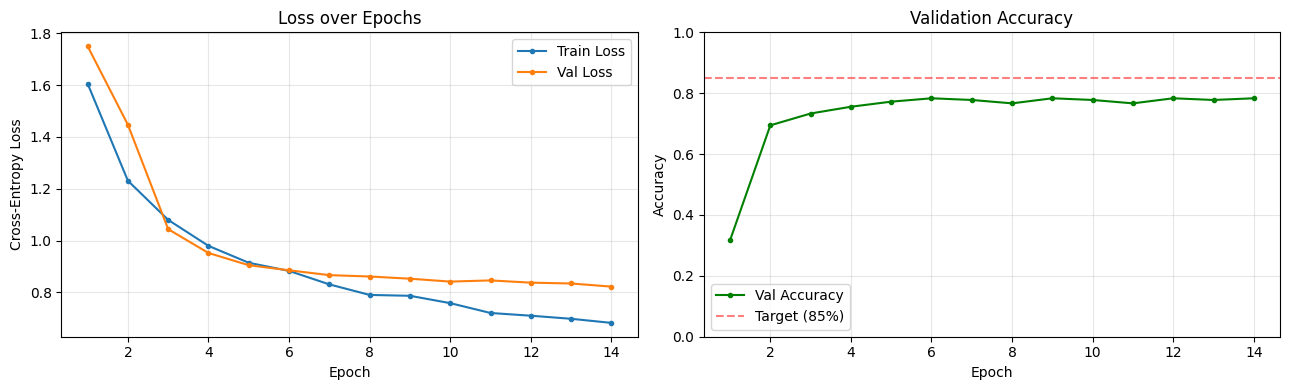

In [11]:
actual_epochs = len(history['train_loss'])
epochs_x = list(range(1, actual_epochs + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_x, history['train_loss'], label='Train Loss', marker='o', markersize=3)
ax1.plot(epochs_x, history['val_loss'],   label='Val Loss',   marker='o', markersize=3)
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, history['val_acc'], label='Val Accuracy', color='green', marker='o', markersize=3)
ax2.axhline(y=0.85, linestyle='--', color='red', alpha=0.5, label='Target (85%)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_ylim(0, 1)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell 6 — Test Evaluation

In [12]:
# Load best checkpoint
eval_model = CareerClassifier(num_classes=num_classes).to(device)
eval_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
eval_model.eval()

test_loader = DataLoader(CareerDataset(X_test, y_test), batch_size=32, shuffle=False)

all_preds, all_true = [], []
with torch.no_grad():
    for texts_batch, labels_batch in test_loader:
        logits = eval_model(list(texts_batch))
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_true.extend(list(labels_batch))

test_acc = accuracy_score(all_true, all_preds)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
if test_acc >= 0.85:
    print('Target of 85% reached!')
else:
    print('Below 85% — consider more epochs or data augmentation.')

target_names = [id_to_label[i] for i in range(num_classes)]
print('\nClassification Report:')
print(classification_report(all_true, all_preds, target_names=target_names))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8296.30it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test Accuracy: 0.7333 (73.3%)
Below 85% — consider more epochs or data augmentation.

Classification Report:
                      precision    recall  f1-score   support

               AI/ML       0.74      0.93      0.82        30
  Business Analytics       0.71      0.73      0.72        30
        Data Science       0.48      0.37      0.42        30
Software Engineering       1.00      0.47      0.64        30
        UX/UI Design       0.97      0.97      0.97        30
     Web Development       0.64      0.93      0.76        30

            accuracy                           0.73       180
           macro avg       0.75      0.73      0.72       180
        weighted avg       0.75      0.73      0.72       180



## Cell 7 — Confusion Matrix

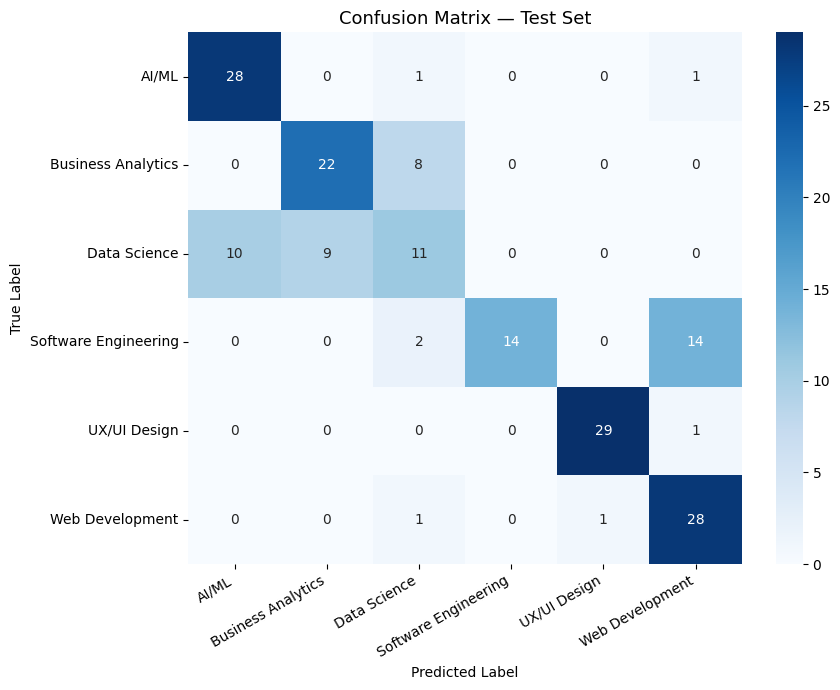

In [13]:
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Cell 8 — Inference Test & Save

In [14]:
def predict_career(profile_dict):
    text = profile_to_text(profile_dict)
    with torch.no_grad():
        logits = eval_model([text])
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    top3_idx = probs.argsort()[::-1][:3]
    top3 = [(id_to_label[int(i)], round(float(probs[i]) * 100, 2)) for i in top3_idx]
    return {'top_prediction': top3[0][0], 'top3': top3}


# Test profiles
test_profiles = [
    ('AI/ML candidate', {
        'skills': ['Python', 'PyTorch', 'TensorFlow', 'scikit-learn', 'Linear Algebra'],
        'interests': ['deep learning', 'computer vision', 'research'],
        'academic_performance': {'math': 19, 'sciences': 18, 'languages': 12, 'arts': 8},
        'projects': ['ResNet-50 from scratch', 'Fine-tuned BERT for sentiment analysis'],
        'goals': {'salary_expectation': '85000', 'remote_preference': 'remote', 'target_field': 'autonomous systems'},
    }),
    ('Ambiguous DS/BA', {
        'skills': ['SQL', 'Excel', 'Power BI', 'Python basics', 'statistics'],
        'interests': ['market trends', 'data storytelling', 'business strategy'],
        'academic_performance': {'math': 15, 'sciences': 13, 'languages': 16, 'arts': 11},
        'projects': ['Sales dashboard in Power BI', 'Customer segmentation analysis'],
        'goals': {'salary_expectation': '48000', 'remote_preference': 'hybrid', 'target_field': 'retail analytics'},
    }),
]

for name, profile in test_profiles:
    result = predict_career(profile)
    print(f'\n-- {name} --')
    print(f"  Top: {result['top_prediction']}")
    for rank, (label, pct) in enumerate(result['top3'], 1):
        print(f'  {rank}. {label:<25} {pct:5.1f}%')

# ── Save final model ─────────────────────────────────────────────────────────
torch.save(eval_model.state_dict(), FINAL_MODEL_PATH)
model_mb = FINAL_MODEL_PATH.stat().st_size / (1024**2)

print(f'\n{"=" * 50}')
print(f'  Final model saved to {FINAL_MODEL_PATH}')
print(f'  Model size: {model_mb:.2f} MB')
print(f'  Best val acc: {best_val_acc:.4f}  |  Test acc: {test_acc:.4f}')
print(f'{"=" * 50}')


-- AI/ML candidate --
  Top: AI/ML
  1. AI/ML                      48.4%
  2. Data Science               26.8%
  3. Software Engineering       13.6%

-- Ambiguous DS/BA --
  Top: Business Analytics
  1. Business Analytics         63.1%
  2. Data Science               25.6%
  3. Software Engineering        3.5%

  Final model saved to ..\models\career_model.pt
  Model size: 87.20 MB
  Best val acc: 0.7833  |  Test acc: 0.7333
